### Google Driveの共有リンクからpandasでCSVを読み込む

- 注意点
  - アクセス権限を「リンクを知っている全員」に設定する必要がある．
  - 「制限付き」にするとエラーが出る．
  - 一時的に「リンクを知っている全員」に設定して，その後に「制限付き」に戻せばセキュリテイを保てる．
  - google drive上でファイルを削除しても，ゴミ箱に移動するだけなので，リンクは有効なまま．
- 手順
  - google driveから共有リンクを取得
    - `https://drive.google.com/file/d/~~~~~/view?usp=drive_link`
  - `~~~~`の部分をコピーして以下の`<id>`部分を置き換える
    - `https://drive.google.com/uc?export=download&id=<id>`
  - 置き換えたURLを`pd.read_csv`に渡す


In [ ]:
import pandas as pd
# https://drive.google.com/file/d/1Wotyr98qTFXqINCnfadKWfBDkQBcb2By/view?usp=sharing
url = 'https://drive.google.com/uc?export=download&id=1Wotyr98qTFXqINCnfadKWfBDkQBcb2By'
df  = pd.read_csv(url)

In [9]:
df

,id,name,out,resume,ball_touch
0,1,first_start,0,1,0
1,2,first_finish,1,0,0
2,3,second_start,0,1,0
3,4,second_finish,1,0,0
4,5,overtime_first_half_start,0,1,0
5,6,overtime_first_half_end,1,0,0
6,7,overtime_second_half_start,0,1,0
7,8,overtime_second_half_end,1,0,0
8,9,second_overtime_first_half_start,0,1,0
9,10,second_overtime_first_half_end,1,0,0


## イベントデータの解析

**問題C：シュート距離とシュート成功率の関係**

好きなリーグのイベントデータをダウンロードしてpandasのDataFrameに読み込め．

In [ ]:
# 解答欄
df_event = pd.read_csv('./event_England.csv')

`df_event`から以下の条件でシュートイベントだけを抽出し，新たに`df_shot`というDataFrameに保存せよ．<br>

In [ ]:
df_shot = df_event.loc[(df_event['event']=='shot') | (df_event['event']=='free_kick'), ['x1', 'y1', 'goal']]

`df_shot`に新たに`success`列を追加し，成功したシュートには1，失敗したシュートには0を設定せよ．

In [ ]:
df_shot['success'] = 0
df_shot.loc[df_shot['goal']==1, 'success'] = 1  # シュート成功を1に設定

`df_shot`に新たに`distance`列を追加し，シュート距離（シュートの開始座標から相手ゴールの中心までの距離）を計算して保存せよ．
- 相手ゴールの中心の座標は $(100, 50)$ である．

In [ ]:
df_shot['distance'] = np.sqrt((df_shot['x1'] - 100)**2 + (df_shot['y1'] - 50)**2)

`df_shot['distance']`の値を以下のように5m単位に丸めよ．

In [ ]:
df_shot['distance'] = np.round(df_shot['distance']/5, 0)*5 # 5m単位に丸める

以下のコードを実行し，シュート距離の値ごとにシュート成功率を計算せよ．<br>
- `groupby`メソッドを用いて`df_shot`を`distance`列の値でグループ化する
- グループごとに`'success'`の平均値を計算してシュート成功率を求める

In [ ]:
distance = df_shot.groupby('distance')['success'].mean().index  # シュート距離
success_rate = df_shot.groupby('distance')['success'].mean().values  # シュート成功率

シュート距離とシュート成功率の関係を散布図で可視化せよ．

Text(0, 0.5, 'Success Rate')

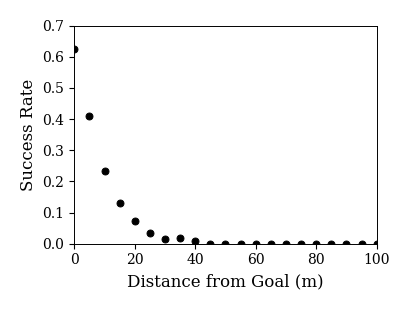

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(distance, success_rate, 'ok')

ax.set_xlim(0, 100)  
ax.set_ylim(0, 0.7)
ax.set_xlabel('Distance from Goal (m)', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)

- この散布図を用いると，シュート位置のデータ（座標）が与えられたときに，シュート成功率を予測することができる．
- このような予測モデルを得点期待値モデル（Expected Goals Model, xGモデル）と呼ぶ．